This file will be used to find the filenames for each current correlation data point to send to Josh so he can run his error bar algorithm on it

In [55]:
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(r"C:\Users\mattm\OneDrive\Desktop\Research\Projects\Triangle Lattice\Jupyter Notebooks\8Q_Triangle_Lattice_v1\paper_data_and_simulations\helpers")


from data_file_helpers import *

In [12]:
coupling_points = [
    'coupling_point_1',
    'coupling_point_2',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5',
    'coupling_point_6',
    'coupling_point_5_retake',
    'coupling_point_6_retake'
]

all_eigenstates = [
    'highest',
    'highest_postselection',
]

In [13]:
config_filename = '../bond_order_config.json'
data_filename = '../bond_order_data.h5'

config = read_config(config_filename)
data = load_nested_dict_from_hdf5(data_filename)

# print_tree(config, max_level=5)
print_tree(data, max_level=5)


data
- coupling_point_1
- - highest
- - - (1, 2)
- - - - population_difference
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - (2, 3)
- - - - population_difference
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - (3, 4)
- - - - population_difference
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - (4, 5)
- - - - population_difference
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - (5, 6)
- - - - population_difference
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - b

In [5]:
eigenstate = 'highest'

pairs = [(i,i+1) for i in range(1,8)]

pair_to_configuration = {
    (1,2): '12-34-56-78',
    (2,3): '1-23-45-67-8',
    (3,4): '12-34-56-78',
    (4,5): '1-23-45-67-8',
    (5,6): '12-34-56-78',
    (6,7): '1-23-45-67-8',
    (7,8): '12-34-56-78'
}

In [6]:

error_bar_data = {}

for i in range(len(coupling_points)):
    coupling_point = coupling_points[i]

    coupling_point_config = config[coupling_point]['data_config']
    coupling_point_data = data['data'][coupling_point]

    print(f'coupling_point: {coupling_point}')

    error_bar_data[coupling_point] = {}

    for i in range(len(pairs)):
        print(f'  pair: {pairs[i]}')
        configuration = pair_to_configuration[pairs[i]]
        pair_config = coupling_point_config[configuration][eigenstate]

        error_bar_data[coupling_point][str(pairs[i])] = {}

        if 'year' in pair_config:
            year = pair_config['year']
            month = pair_config['month']
            day = pair_config['day']
            hour = pair_config['hour']
            minute = pair_config['minute']
            second = pair_config['second']

            filename_base = pair_config['filename_base']


            datecode = str(month) + str(day)
            timecode = str(hour) + str(minute) + str(second)

            error_bar_data[coupling_point][str(pairs[i])]['file_code'] = (year, datecode, timecode, filename_base)


        elif 'filename' in pair_config:
            filename = pair_config['filename']
            error_bar_data[coupling_point][str(pairs[i])]['filename'] = filename
        else:
            raise ValueError("No year or filename found in config for pair {}".format(pairs[i]))

        # index

        correlation_pair_data = coupling_point_data[eigenstate][str(pairs[i])]

        correlation_value = correlation_pair_data['bond_order_value_corrected']
        error_bar_data[coupling_point][str(pairs[i])]['bond_order_value_corrected'] = correlation_value

        
    print()

NameError: name 'config' is not defined

In [25]:
print_tree(error_bar_data, max_level=5)

coupling_point_1
- (1, 2)
- - file_code
- - bond_order_value_corrected
- (2, 3)
- - file_code
- - bond_order_value_corrected
- (3, 4)
- - file_code
- - bond_order_value_corrected
- (4, 5)
- - file_code
- - bond_order_value_corrected
- (5, 6)
- - file_code
- - bond_order_value_corrected
- (6, 7)
- - file_code
- - bond_order_value_corrected
- (7, 8)
- - file_code
- - bond_order_value_corrected
coupling_point_2
- (1, 2)
- - file_code
- - bond_order_value_corrected
- (2, 3)
- - file_code
- - bond_order_value_corrected
- (3, 4)
- - file_code
- - bond_order_value_corrected
- (4, 5)
- - file_code
- - bond_order_value_corrected
- (5, 6)
- - file_code
- - bond_order_value_corrected
- (6, 7)
- - file_code
- - bond_order_value_corrected
- (7, 8)
- - file_code
- - bond_order_value_corrected
coupling_point_3
- (1, 2)
- - file_code
- - bond_order_value_corrected
- (2, 3)
- - file_code
- - bond_order_value_corrected
- (3, 4)
- - file_code
- - bond_order_value_corrected
- (4, 5)
- - file_code
- - bond

In [26]:
error_bar_data_filename = 'bond_order_error_bar_config.h5'
save_nested_dict_to_hdf5(error_bar_data_filename, error_bar_data, save_backup=False)

In [27]:
loaded_error_bar_data = load_nested_dict_from_hdf5(error_bar_data_filename)
print(loaded_error_bar_data['coupling_point_1']['(1, 2)'])
print_tree(loaded_error_bar_data)

{'bond_order_value_corrected': -0.46422442432358324, 'file_code': array(['2025', '1208', '102456', 'BSClean_Correlations'], dtype=object)}
coupling_point_1
- (1, 2)
- - bond_order_value_corrected
- - file_code
- (2, 3)
- - bond_order_value_corrected
- - file_code
- (3, 4)
- - bond_order_value_corrected
- - file_code
- (4, 5)
- - bond_order_value_corrected
- - file_code
- (5, 6)
- - bond_order_value_corrected
- - file_code
- (6, 7)
- - bond_order_value_corrected
- - file_code
- (7, 8)
- - bond_order_value_corrected
- - file_code
coupling_point_2
- (1, 2)
- - bond_order_value_corrected
- - file_code
- (2, 3)
- - bond_order_value_corrected
- - file_code
- (3, 4)
- - bond_order_value_corrected
- - file_code
- (4, 5)
- - bond_order_value_corrected
- - file_code
- (5, 6)
- - bond_order_value_corrected
- - file_code
- (6, 7)
- - bond_order_value_corrected
- - file_code
- (7, 8)
- - bond_order_value_corrected
- - file_code
coupling_point_3
- (1, 2)
- - bond_order_value_corrected
- - file_code


# 2. Export Error Bar Data
This part takes the resampled data from Josh's algorithm and adds the error bars to the `bond_order_data.h5` data file.

In [14]:
bond_order_config_filename = '..\\bond_order_config.json'
loaded_bond_order_config = read_config(bond_order_config_filename)
# print_tree(loaded_bond_order_config['coupling_point_1'])

In [15]:
bond_order_data_filename = '..\\bond_order_data.h5'
backup_dir = 'data_backups'
loaded_bond_order_data = load_nested_dict_from_hdf5(bond_order_data_filename)
print_tree(loaded_bond_order_data['data']['coupling_point_1']['highest'], max_level=1)

(1, 2)
(2, 3)
(3, 4)
(4, 5)
(5, 6)
(6, 7)
(7, 8)
bond_order_total
bond_order_total_corrected
bond_order_total_error
bond_order_total_error_corrected


In [44]:
bootstrap_filename = 'bootstrapped_bond_pops_config.h5'

loaded_bootstrap_data = load_nested_dict_from_hdf5(bootstrap_filename)
# print_tree(loaded_bootstrap_data)
print(loaded_bootstrap_data['coupling_point_1']['(1, 2)']['resampled_pop_means'])
# print_tree(loaded_bootstrap_data['coupling_point_5_retake'])

[[0.43324564 0.38857426 0.36451886 0.33405563 0.30137973 0.29188486
  0.27332444 0.26224199 0.26546445 0.26364037 0.27840983 0.29414416
  0.32171093 0.34907907 0.38625689 0.42149517 0.46726083 0.50925295
  0.54532754 0.5831209  0.60698137 0.64369263 0.6727631  0.68881104
  0.69009877 0.71860251 0.7175094  0.72312814 0.70202629 0.69125825
  0.67930297 0.66086722 0.62464955 0.58359418 0.54608466 0.50308769
  0.4752756  0.44140051 0.40408845 0.37612686 0.33014282 0.30413768
  0.29343989 0.2941826  0.28254145 0.27192572 0.2807324  0.27761484
  0.31747758 0.34443491 0.364303   0.40432249 0.4449844  0.48476915
  0.51045645 0.54558479 0.59639338 0.62516277 0.66045697 0.68765059
  0.70472215 0.71880357 0.71455665 0.71842774 0.71603268 0.70325622
  0.69720822 0.67166765 0.64172465 0.62100482 0.58363886]
 [0.52482813 0.57177145 0.61901663 0.64635491 0.69913247 0.70299661
  0.72359206 0.73577738 0.71998821 0.72096902 0.70527915 0.6831195
  0.66787013 0.6378421  0.60423853 0.55604963 0.52809049 0.

In [51]:
for i in range(len(coupling_points)):
    coupling_point = coupling_points[i]

    print(f'processing coupling point {coupling_point}')

    for j in range(len(all_eigenstates)):

        eigenstate = all_eigenstates[j]

        print(eigenstate)

        if not eigenstate in loaded_bond_order_data['data'][coupling_point]:
            print(f'eigenstate {eigenstate} not found for coupling point {coupling_point} in correlation data')
            continue

        if not eigenstate in loaded_bootstrap_data[coupling_point]:
            if not eigenstate == 'highest':
                # for now treat everything as highest since we don't distinguish highest vs highest_postselection in the bootstrap data (yet)
                print(f'eigenstate {eigenstate} not found for coupling point {coupling_point} in bootstrap data')
                continue
        
        data_dictionary = loaded_bond_order_data['data'][coupling_point][eigenstate]

        
        for k in range(len(pairs)):
            pair = pairs[k]

            if str(pair) not in loaded_bootstrap_data[coupling_point]:
                print(f'correlation pair {pair} not found for coupling point {coupling_point} in bootstrap data')

            if not 'resampled_pop_means' in loaded_bootstrap_data[coupling_point][str(pair)]:
                print(f'failed for coupling point {coupling_point} correlation pair {pair}')
                continue

            readout_error_means_all_qubits = loaded_bootstrap_data[coupling_point][str(pair)]['resampled_pop_means']
            readout_error_stds_all_qubits = loaded_bootstrap_data[coupling_point][str(pair)]['resampled_pop_stds']

            readout_error_means = readout_error_means_all_qubits[pairs[k][1]-1] - readout_error_means_all_qubits[pairs[k][0]-1]
            readout_error_stds = np.sqrt(np.power(readout_error_stds_all_qubits[pairs[k][1]-1],2) +  np.power(readout_error_stds_all_qubits[pairs[k][0]-1],2))

            times = loaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['times']

            beamsplitter_time = loaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['beamsplitter_time']
            time_index = np.argmin(np.abs(times - beamsplitter_time))


            # add in coupling units here
            data_dictionary[str(pair)]['readout_error_means'] = readout_error_means
            data_dictionary[str(pair)]['readout_error_stds'] = readout_error_stds

            # print(times)

            bond_order_value_readout_std_error = data_dictionary[str(pair)]['readout_error_stds'][time_index]
            data_dictionary[str(pair)]['bond_order_value_readout_std_error'] = bond_order_value_readout_std_error


        # set total chiral current error

        bond_order_value_readout_std_errors = [data_dictionary[str(pair)]['bond_order_value_readout_std_error'] for pair in pairs]

        bond_order_total_readout_std_error = np.sqrt(np.sum(np.power(bond_order_value_readout_std_errors, 2)))

        data_dictionary['bond_order_total_readout_std_error'] = bond_order_total_readout_std_error

        keys = ('data',coupling_point, eigenstate)
        update_data_file(bond_order_data_filename, data_dictionary, keys, backup_dir=backup_dir, save_backup=True)



processing coupling point coupling_point_1
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_1 in bootstrap data
processing coupling point coupling_point_2
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_2 in bootstrap data
processing coupling point coupling_point_3
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_3 in bootstrap data
processing coupling point coupling_point_4
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_4 in bootstrap data
processing coupling point coupling_point_5
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_5 in bootstrap data
processing coupling point coupling_point_6
highest
highest_postselection
eigenstate highest_postselection not found for coupling point coupling_point_

In [57]:
bond_order_data_filename = '..\\bond_order_data.h5'
backup_dir = 'data_backups'
reloaded_bond_order_data = load_nested_dict_from_hdf5(bond_order_data_filename)
print_tree(reloaded_bond_order_data['data']['coupling_point_3']['highest'], max_level=2)

(1, 2)
- population_difference
- readout_error_means
- readout_error_stds
- times
- beamsplitter_time
- bond_order_error
- bond_order_error_corrected
- bond_order_value
- bond_order_value_corrected
- bond_order_value_readout_std_error
(2, 3)
- population_difference
- readout_error_means
- readout_error_stds
- times
- beamsplitter_time
- bond_order_error
- bond_order_error_corrected
- bond_order_value
- bond_order_value_corrected
- bond_order_value_readout_std_error
(3, 4)
- population_difference
- readout_error_means
- readout_error_stds
- times
- beamsplitter_time
- bond_order_error
- bond_order_error_corrected
- bond_order_value
- bond_order_value_corrected
- bond_order_value_readout_std_error
(4, 5)
- population_difference
- readout_error_means
- readout_error_stds
- times
- beamsplitter_time
- bond_order_error
- bond_order_error_corrected
- bond_order_value
- bond_order_value_corrected
- bond_order_value_readout_std_error
(5, 6)
- population_difference
- readout_error_means
- reado

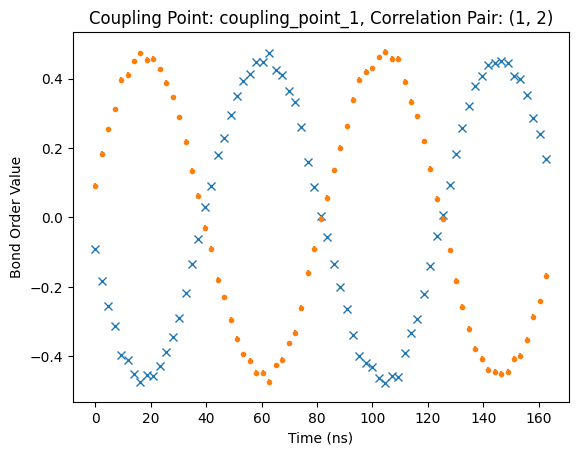

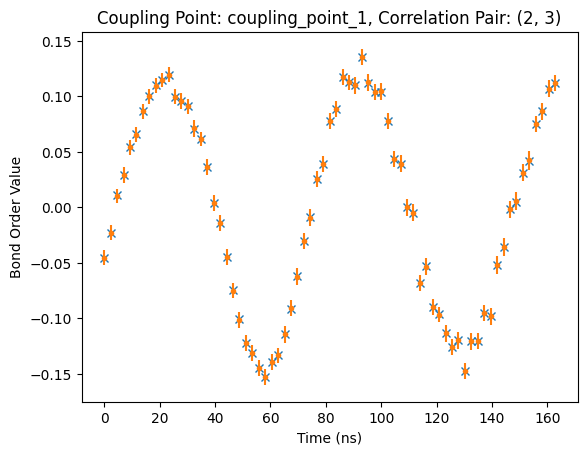

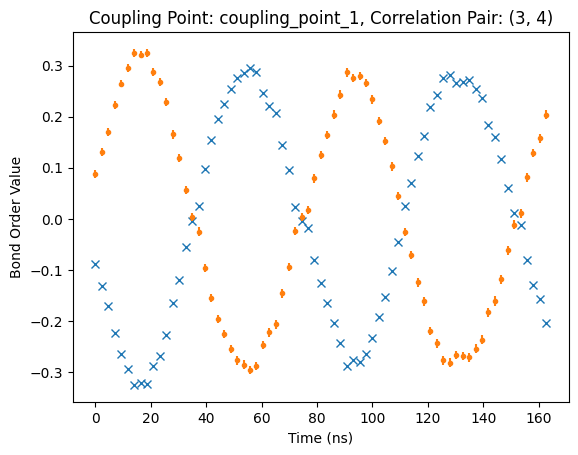

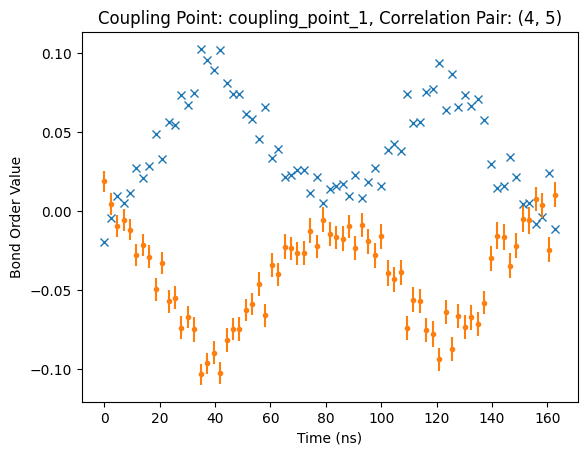

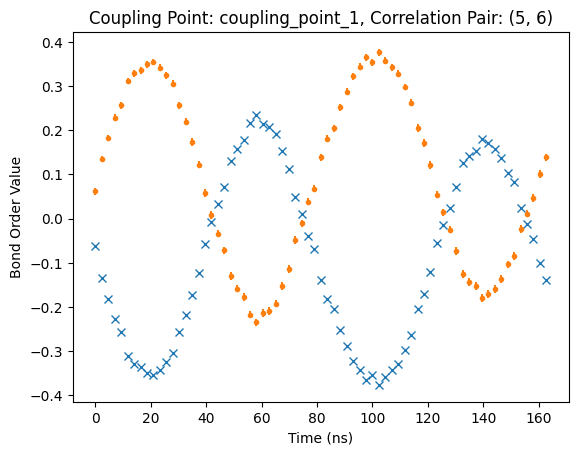

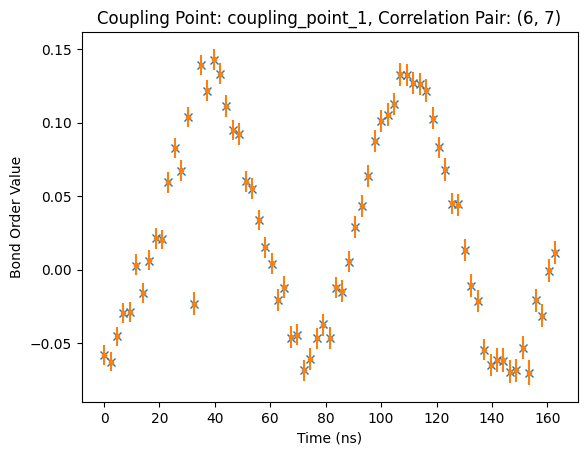

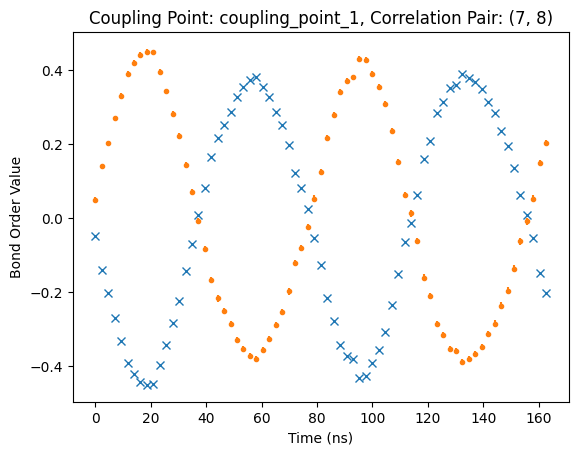

In [60]:
for coupling_point in coupling_points:

    if not coupling_point in ['coupling_point_1']:
        continue

    eigenstate = 'highest_postselection'
    eigenstate = 'highest'

    for pair in pairs:
        if 'readout_error_means' not in reloaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]:
            # print(f'correlation pair {correlation_pair} not found for coupling point {coupling_point} in bootstrap data')
            continue

        times = reloaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['times']
        population_difference = reloaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['population_difference']
        readout_error_means = reloaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['readout_error_means']
        readout_error_stds = reloaded_bond_order_data['data'][coupling_point][eigenstate][str(pair)]['readout_error_stds']



        plt.plot(times, population_difference, linestyle='', marker='x', label='bond order')
        # plt.plot(times, readout_error_means, linestyle='', marker='o', label='readout error mean')

        

        plt.errorbar(times, readout_error_means, yerr=readout_error_stds, fmt='o', markersize=3, label='bond order with error bars')
    
        plt.xlabel('Time (ns)')
        plt.ylabel('Bond Order Value')
        plt.title(f'Coupling Point: {coupling_point}, Correlation Pair: {pair}')
        plt.show()

                                                                                

In [ ]:
# ### copy all post selected and corrected error bars to just post selection

# for i in range(len(coupling_points)):
#     coupling_point = coupling_points[i]

#     for k in range(len(correlation_pairs)):
#         correlation_pair = correlation_pairs[k]

#         if not str(correlation_pair) in reloaded_correlation_data['data'][coupling_point]['highest']:
#             continue

#         data_dictionary = reloaded_correlation_data['data'][coupling_point]['highest'][str(correlation_pair)]


#         keys = ('data',coupling_point, 'highest_postselection', str(correlation_pair))
#         update_data_file(correlation_data_filename, data_dictionary, keys, backup_dir=backup_dir, save_backup=True)